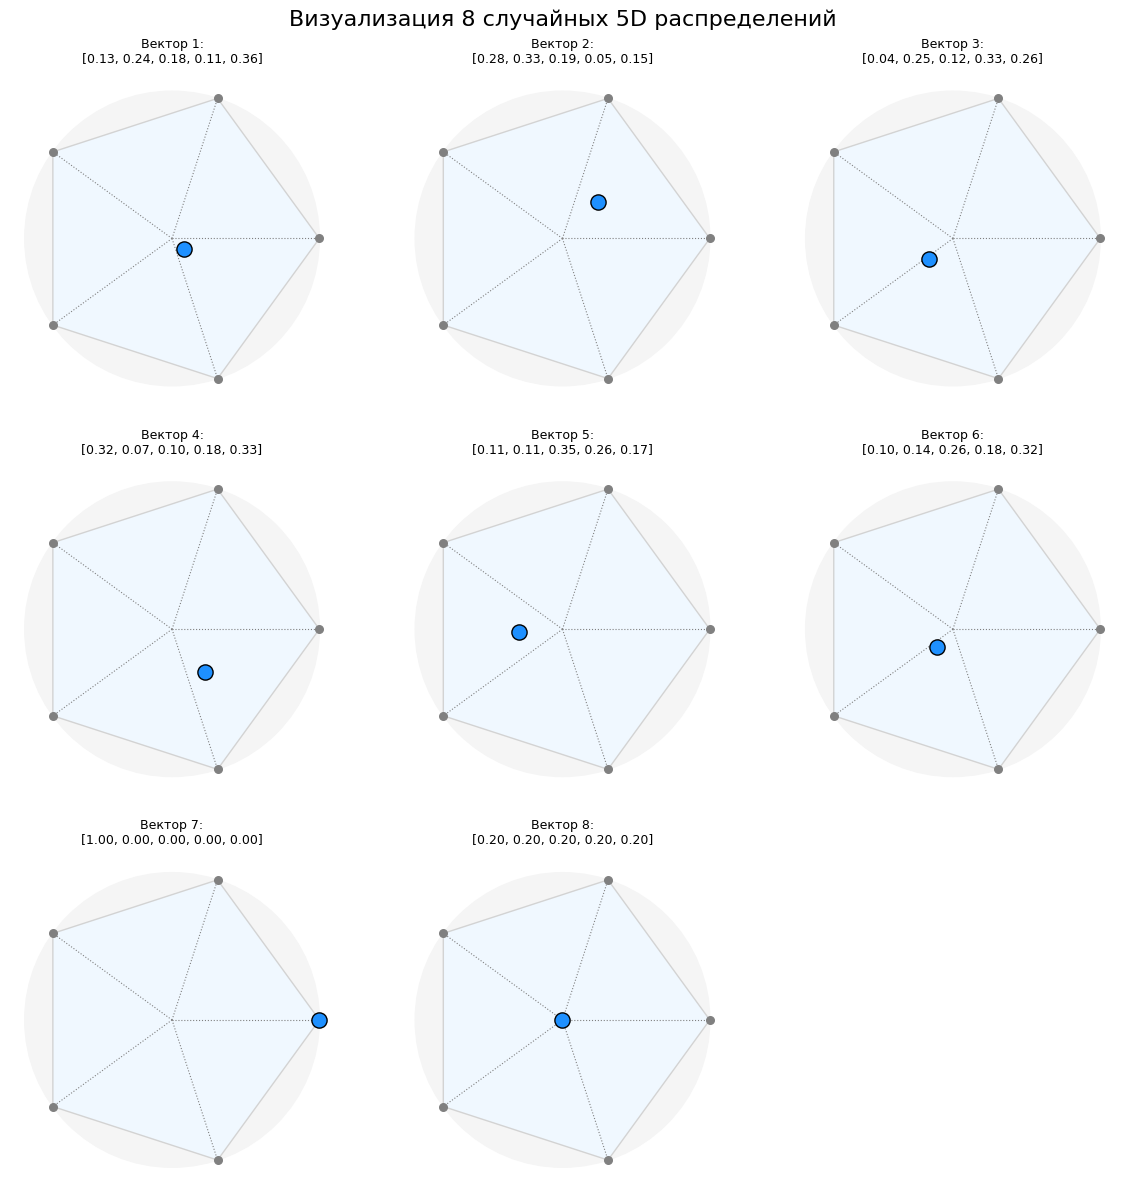

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import math


def visualize_distribution_vector(ax, vector, title=""):
    """
    Визуализирует N-мерный вектор-распределение (сумма=1) как одну точку
    внутри единичного круга. Вычисления производятся с помощью PyTorch.

    Args:
        ax (matplotlib.axes.Axes): Объект осей, на котором будет строиться график.
        vector (list, np.array, or torch.Tensor): N-мерный вектор.
        title (str): Заголовок для графика.
    """
    # 1. Преобразование в тензор и нормализация
    if not isinstance(vector, torch.Tensor):
        vector_tensor = torch.tensor(vector, dtype=torch.float32)
    else:
        vector_tensor = vector.to(torch.float32)

    # Принудительная нормализация, чтобы гарантировать, что сумма = 1
    vec_sum = torch.sum(vector_tensor)
    if vec_sum > 0:
        vector_tensor /= vec_sum
    else:
        # Если вектор нулевой, считаем его равномерным распределением
        # Это предотвратит деление на ноль и даст точку в центре
        n_dims_check = len(vector_tensor)
        if n_dims_check > 0:
            vector_tensor = torch.ones(n_dims_check) / n_dims_check

    n_dims = len(vector_tensor)

    # Обработка пустого вектора
    if n_dims == 0:
        ax.text(0.5, 0.5, "Пустой вектор", ha="center", va="center")
        ax.axis("off")
        return

    # 2. Вычисления с использованием PyTorch
    # Создаем тензор углов для якорей (имитируем endpoint=False)
    angles = torch.linspace(0, 2 * torch.pi, steps=n_dims + 1)[:-1]

    anchors_x = torch.cos(angles)
    anchors_y = torch.sin(angles)

    # Упрощенная формула для векторов-распределений (сумма весов = 1)
    final_x_tensor = torch.sum(vector_tensor * anchors_x)
    final_y_tensor = torch.sum(vector_tensor * anchors_y)

    # 3. Конвертация из тензоров в типы для Matplotlib
    anchors_x_np = anchors_x.numpy()
    anchors_y_np = anchors_y.numpy()
    final_x = final_x_tensor.item()
    final_y = final_y_tensor.item()

    # --- Отрисовка ---
    ax.clear()
    ax.set_aspect("equal", "box")
    ax.axis("off")

    # Рисуем фон и выпуклую оболочку
    circle_bg = Circle((0, 0), 1, color="whitesmoke", zorder=1)
    ax.add_patch(circle_bg)
    convex_hull = plt.Polygon(
        np.column_stack((anchors_x_np, anchors_y_np)),
        edgecolor="lightgray",
        facecolor="aliceblue",
        linewidth=1,
        zorder=2,
    )
    ax.add_patch(convex_hull)

    # Рисуем якоря и оси
    ax.scatter(anchors_x_np, anchors_y_np, color="gray", s=30, zorder=3)
    for i in range(n_dims):
        ax.plot(
            [0, anchors_x_np[i]],
            [0, anchors_y_np[i]],
            color="gray",
            linestyle=":",
            linewidth=0.8,
            zorder=2,
        )

    # Рисуем итоговую точку
    ax.scatter(
        final_x,
        final_y,
        color="dodgerblue",
        s=120,
        zorder=4,
        marker="o",
        edgecolors="black",
    )

    if title:
        ax.set_title(title, pad=10, fontsize=9)


def generate_random_distributions(num_vectors, dim):
    """Генерирует список случайных векторов-распределений."""
    vectors = []
    for _ in range(num_vectors):
        # Генерируем случайный тензор
        random_tensor = torch.rand(dim)
        # Нормализуем его, чтобы сумма стала равна 1
        vectors.append(random_tensor / torch.sum(random_tensor))
    return vectors


# --- Основной скрипт для запуска ---

if __name__ == "__main__":
    # --- НАСТРОЙКИ ---
    NUM_VECTORS_TO_PLOT = 6  # Сколько графиков нарисовать
    vector_dim = 5  # Размерность каждого вектора

    # Генерируем список случайных векторов
    list_of_vectors = generate_random_distributions(NUM_VECTORS_TO_PLOT, vector_dim)

    # Добавим несколько интересных случаев вручную для наглядности
    list_of_vectors.append(torch.tensor([1.0, 0.0, 0.0, 0.0, 0.0]))  # Концентрация
    list_of_vectors.append(torch.tensor([0.2, 0.2, 0.2, 0.2, 0.2]))  # Равномерное

    # --- Динамическое создание сетки графиков ---
    num_plots = len(list_of_vectors)
    # Вычисляем количество строк и столбцов для сетки
    cols = math.ceil(math.sqrt(num_plots))
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    # Превращаем массив осей в одномерный для удобной итерации
    axes = axes.flatten()

    # Рисуем график для каждого вектора
    for i, vector in enumerate(list_of_vectors):
        # Форматируем заголовок для красивого вывода
        vec_str = ", ".join([f"{x:.2f}" for x in vector])
        title = f"Вектор {i+1}:\n[{vec_str}]"
        visualize_distribution_vector(axes[i], vector, title)

    # Скрываем лишние пустые графики, если они есть
    for i in range(num_plots, len(axes)):
        axes[i].axis("off")

    plt.tight_layout(pad=2.0)
    plt.suptitle(
        f"Визуализация {num_plots} случайных {vector_dim}D распределений",
        fontsize=16,
        y=1.0,
    )
    plt.show()

Генерация случайного вектора размерности 128256...
Вычисление координат итоговой точки...
Вычисления заняли: 0.0004 секунд.
Координаты итоговой точки: (0.0006, 0.0007)


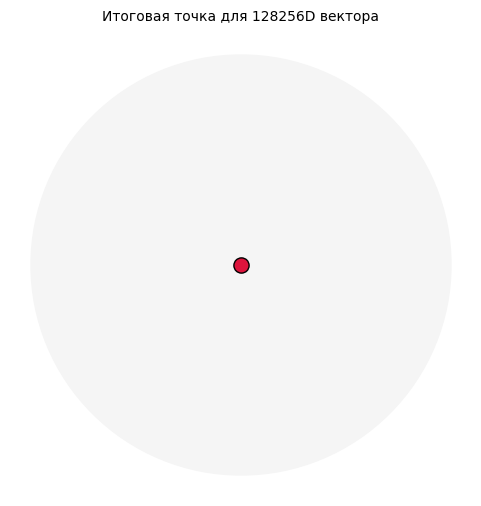

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import time


def calculate_point_for_high_dim_vector(vector):
    """
    Вычисляет координаты точки для вектора очень высокой размерности.
    Не производит отрисовку, только возвращает координаты.
    """
    if not isinstance(vector, torch.Tensor):
        vector_tensor = torch.tensor(vector, dtype=torch.float32)
    else:
        vector_tensor = vector.to(torch.float32)

    vec_sum = torch.sum(vector_tensor)
    if vec_sum > 0:
        vector_tensor /= vec_sum
    else:  # Обработка нулевого вектора
        return 0.0, 0.0

    n_dims = len(vector_tensor)
    if n_dims == 0:
        return 0.0, 0.0

    # Создаем тензор углов для якорей
    angles = torch.linspace(0, 2 * torch.pi, steps=n_dims + 1)[:-1]

    # Вычисляем координаты точки
    final_x = torch.sum(vector_tensor * torch.cos(angles)).item()
    final_y = torch.sum(vector_tensor * torch.sin(angles)).item()

    return final_x, final_y


def plot_point_only(ax, coords, title):
    """Рисует только круг и итоговую точку."""
    ax.clear()
    ax.set_aspect("equal", "box")
    ax.axis("off")

    circle_bg = Circle((0, 0), 1, color="whitesmoke", zorder=1)
    ax.add_patch(circle_bg)
    ax.scatter(0, 0, color="black", s=10, zorder=2, alpha=0.5)

    ax.scatter(
        coords[0],
        coords[1],
        color="crimson",
        s=120,
        zorder=3,
        marker="o",
        edgecolors="black",
    )
    ax.set_title(title, pad=10, fontsize=10)


# --- Основной скрипт ---
if __name__ == "__main__":
    vector_dim = 128256

    print(f"Генерация случайного вектора размерности {vector_dim}...")
    # Генерируем случайный тензор и нормализуем его
    random_vector = torch.rand(vector_dim)

    print("Вычисление координат итоговой точки...")
    start_time = time.time()

    # Вычисляем координаты
    final_coords = calculate_point_for_high_dim_vector(random_vector)

    end_time = time.time()
    print(f"Вычисления заняли: {end_time - start_time:.4f} секунд.")
    print(f"Координаты итоговой точки: ({final_coords[0]:.4f}, {final_coords[1]:.4f})")

    # Отрисовка
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_point_only(ax, final_coords, f"Итоговая точка для {vector_dim}D вектора")
    plt.show()

Генерация 128256D вектора с 10 активными измерениями...

--- Информация о векторе ---
Случайно выбранные 'горячие' индексы:
[114898 126500  72182 101171  13252 108843  84889 106594  29372  52526]
Значения в этих индексах (сумма = 1.00):
[0.132  0.2029 0.0178 0.1157 0.2229 0.0054 0.01   0.0736 0.1961 0.0235]

Вычисление координат итоговой точки...
Вычисления заняли: 0.0003 секунд.
Координаты итоговой точки: (0.5356, 0.0477)


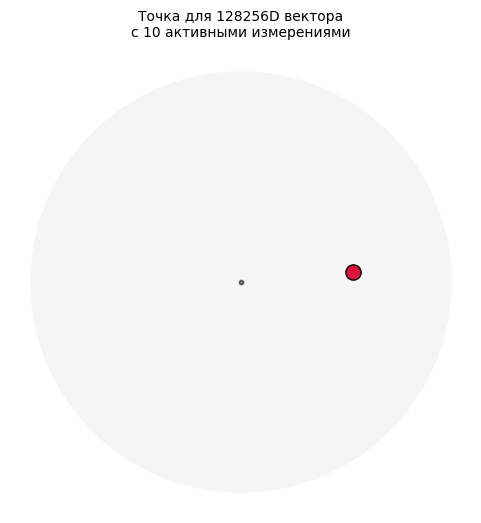


--- Визуализация линейным графиком ---


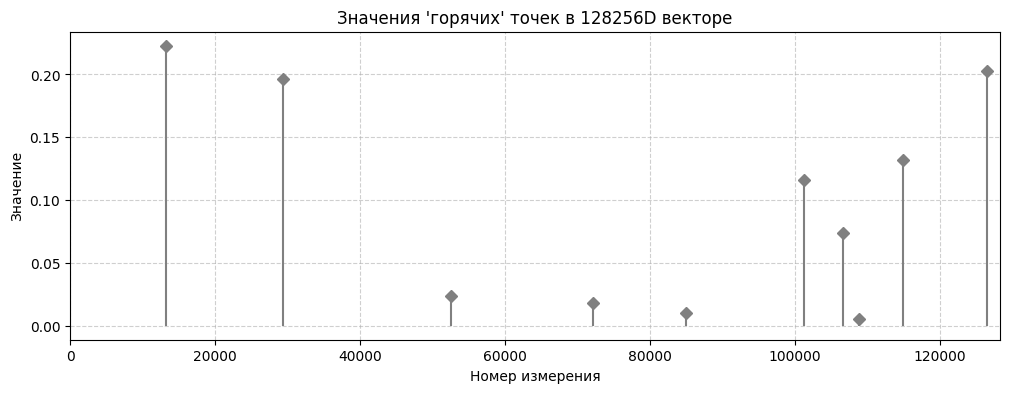

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import time
import math

# --- Копируем вспомогательные функции из предыдущих ответов ---


def calculate_point_for_high_dim_vector(vector):
    """Вычисляет координаты точки для вектора очень высокой размерности."""
    if not isinstance(vector, torch.Tensor):
        vector_tensor = torch.tensor(vector, dtype=torch.float32)
    else:
        vector_tensor = vector.to(torch.float32)

    vec_sum = torch.sum(vector_tensor)
    if vec_sum > 0:
        vector_tensor /= vec_sum
    else:
        return 0.0, 0.0

    n_dims = len(vector_tensor)
    if n_dims == 0:
        return 0.0, 0.0

    angles = torch.linspace(0, 2 * torch.pi, steps=n_dims + 1)[:-1]

    final_x = torch.sum(vector_tensor * torch.cos(angles)).item()
    final_y = torch.sum(vector_tensor * torch.sin(angles)).item()

    return final_x, final_y


def plot_point_only(ax, coords, title):
    """Рисует только круг и итоговую точку."""
    ax.clear()
    ax.set_aspect("equal", "box")
    ax.axis("off")

    circle_bg = Circle((0, 0), 1, color="whitesmoke", zorder=1)
    ax.add_patch(circle_bg)
    ax.scatter(0, 0, color="black", s=10, zorder=2, alpha=0.5)

    ax.scatter(
        coords[0],
        coords[1],
        color="crimson",
        s=120,
        zorder=3,
        marker="o",
        edgecolors="black",
    )
    ax.set_title(title, pad=10, fontsize=10)


def create_sparse_distribution_vector(dim, num_hot_dims):
    """
    Создает разреженный вектор-распределение.

    Args:
        dim (int): Общая размерность вектора.
        num_hot_dims (int): Количество "горячих" (ненулевых) измерений.

    Returns:
        torch.Tensor: Разреженный вектор, сумма которого равна 1.
        torch.Tensor: Индексы "горячих" измерений.
    """
    if num_hot_dims > dim:
        raise ValueError(
            "Количество 'горячих' измерений не может быть больше общей размерности."
        )

    # 1. Начинаем с нулевого вектора
    sparse_vector = torch.zeros(dim, dtype=torch.float32)

    # 2. Выбираем случайные уникальные индексы
    # torch.randperm(dim) создает случайную перестановку чисел от 0 до dim-1
    hot_indices = torch.randperm(dim)[:num_hot_dims]

    # 3. Присваиваем случайные значения этим индексам
    hot_values = torch.rand(num_hot_dims)
    sparse_vector[hot_indices] = hot_values

    # 4. Нормализуем весь вектор
    sparse_vector /= torch.sum(sparse_vector)

    return sparse_vector, hot_indices


# --- Основной скрипт ---
if __name__ == "__main__":
    VECTOR_DIMENSION = 128256
    NUM_HOT_DIMS = 10  # Количество активных измерений

    print(
        f"Генерация {VECTOR_DIMENSION}D вектора с {NUM_HOT_DIMS} активными измерениями..."
    )

    # Создаем наш выразительный вектор
    sparse_vector, hot_indices = create_sparse_distribution_vector(
        VECTOR_DIMENSION, NUM_HOT_DIMS
    )

    # Выведем информацию о созданных "пиках"
    print("\n--- Информация о векторе ---")
    print(f"Случайно выбранные 'горячие' индексы:\n{hot_indices.numpy()}")
    hot_values_normalized = sparse_vector[hot_indices]
    print(
        f"Значения в этих индексах (сумма = {torch.sum(hot_values_normalized):.2f}):\n{hot_values_normalized.numpy().round(4)}"
    )

    # Вычисляем координаты итоговой точки
    print("\nВычисление координат итоговой точки...")
    start_time = time.time()
    final_coords = calculate_point_for_high_dim_vector(sparse_vector)
    end_time = time.time()

    print(f"Вычисления заняли: {end_time - start_time:.4f} секунд.")
    print(f"Координаты итоговой точки: ({final_coords[0]:.4f}, {final_coords[1]:.4f})")

    # Отрисовка
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_point_only(
        ax,
        final_coords,
        f"Точка для {VECTOR_DIMENSION}D вектора\nс {NUM_HOT_DIMS} активными измерениями",
    )
    plt.show()

    # Дополнительно: Нарисуем линейный график, чтобы увидеть "пики"
    print("\n--- Визуализация линейным графиком ---")
    fig_line, ax_line = plt.subplots(figsize=(12, 4))
    # Для наглядности будем рисовать только точки, а не сплошную линию
    ax_line.stem(
        hot_indices.numpy(),
        sparse_vector[hot_indices].numpy(),
        linefmt="grey",
        markerfmt="D",
        basefmt=" ",
    )
    ax_line.set_title(f"Значения 'горячих' точек в {VECTOR_DIMENSION}D векторе")
    ax_line.set_xlabel("Номер измерения")
    ax_line.set_ylabel("Значение")
    ax_line.set_xlim(0, VECTOR_DIMENSION)
    ax_line.grid(True, linestyle="--", alpha=0.6)
    plt.show()